In [1]:
import sys
import os
sys.path.append(os.path.abspath('../utils'))

import pandas as pd
import numpy as np
from data_aggregation_tools import merge_tickets_assets

df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
df_assets = pd.read_csv("../../data/V_OM_WORK_TASK_ASSET.csv")

# Generate merged tickets / assets file
df_tickets_assets = merge_tickets_assets(df_tickets=df_tickets, df_assets=df_assets)

print(f"shape of df_tickets: {df_tickets.shape}")
print(f"shape of df_assets: {df_assets.shape}")
print(f"shape of df_tickets_assets: {df_tickets_assets.shape}")


/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_64654/2984208179.py:9: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_64654/2984208179.py:10: DtypeWarning: Columns (0,3,4,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_assets = pd.read_csv("../../data/V_OM_WORK_TASK_ASSET.csv")


shape of df_tickets: (227205, 47)
shape of df_assets: (316257, 9)
shape of df_tickets_assets: (316257, 55)


## Sanity Checks: Work Tasks & Asset Matching

First, let's ensure that all rows with the same work task ID (same ticket) only show up when it is noted there are multiple assets corresponding to the ticket.

Number of rows with non-unique WORK_TASK_ID values in df_tickets_assets: 93667
Number of rows with non-unique WORK_TASK_ID and NUMBER_OF_ASSETS is 1: 0
Number of rows with non-unique WORK_TASK_ID and NUMBER_OF_ASSETS is 0: 33705


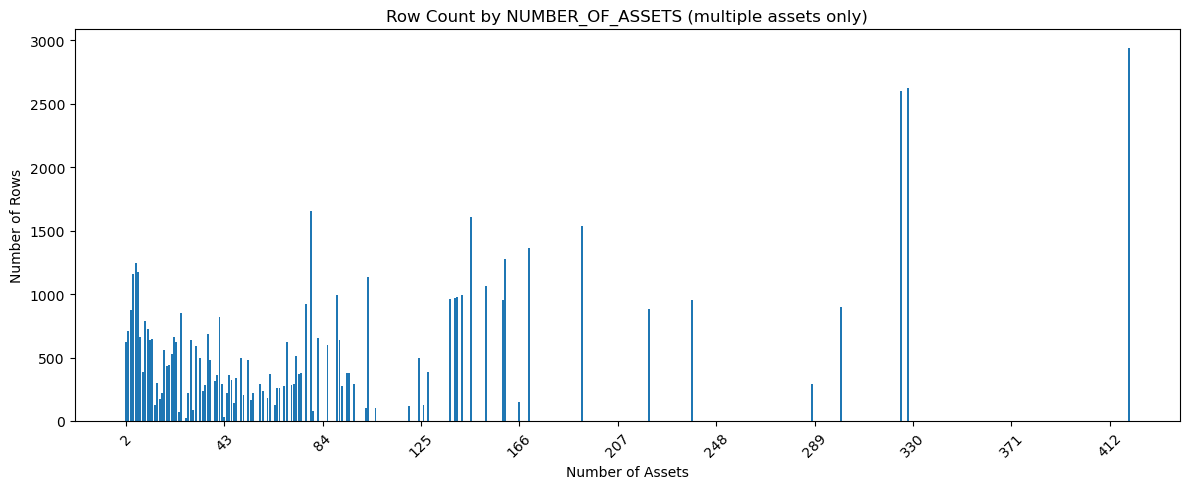

Expected total expected rows based on NUMBER_OF_ASSETS: 7312991
Actual total number of rows: 316257


In [2]:
import matplotlib.pyplot as plt

# Calculate value counts for WORK_TASK_ID
work_task_id_counts = df_tickets_assets['WORK_TASK_ID'].value_counts()

# Identify WORK_TASK_ID values that appear more than once (non-unique)
non_unique_work_task_ids = work_task_id_counts[work_task_id_counts > 1]

# Calculate the total number of rows associated with these non-unique WORK_TASK_IDs
num_rows_with_non_unique_work_task_id = non_unique_work_task_ids.sum()

print(f"Number of rows with non-unique WORK_TASK_ID values in df_tickets_assets: {num_rows_with_non_unique_work_task_id}")

# Get the list of WORK_TASK_IDs that are not unique
non_unique_work_task_ids_list = work_task_id_counts[work_task_id_counts > 1].index.tolist()

# Filter df_tickets_assets to include only rows with these non-unique WORK_TASK_IDs
df_non_unique_work_tasks = df_tickets_assets[df_tickets_assets['WORK_TASK_ID'].isin(non_unique_work_task_ids_list)]

# Count how many of these rows have 'NUMBER_OF_ASSETS' greater than 1
count_assets_less_than_2 = df_non_unique_work_tasks[df_non_unique_work_tasks['NUMBER_OF_ASSETS'] == 1].shape[0]
count_assets_equals_0 = df_non_unique_work_tasks[df_non_unique_work_tasks['NUMBER_OF_ASSETS'] == 0].shape[0]

print(f"Number of rows with non-unique WORK_TASK_ID and NUMBER_OF_ASSETS is 1: {count_assets_less_than_2}")
print(f"Number of rows with non-unique WORK_TASK_ID and NUMBER_OF_ASSETS is 0: {count_assets_equals_0}")

# Filter df_non_unique_work_tasks to find rows where NUMBER_OF_ASSETS is 0 or 1
sample_rows_zero_assets = df_non_unique_work_tasks[df_non_unique_work_tasks['NUMBER_OF_ASSETS'] == 0]
sample_rows_multiple_assets = df_non_unique_work_tasks[df_non_unique_work_tasks['NUMBER_OF_ASSETS'] > 1]


df_filtered = df_tickets_assets[df_tickets_assets['NUMBER_OF_ASSETS'] >= 2]['NUMBER_OF_ASSETS'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(df_filtered.index, df_filtered.values)

plt.xlabel('Number of Assets')
plt.ylabel('Number of Rows')
plt.title('Row Count by NUMBER_OF_ASSETS (multiple assets only)')

# Show only 10 evenly spaced labels
plt.xticks(range(df_filtered.index.min(), df_filtered.index.max(), 
           (df_filtered.index.max() - df_filtered.index.min()) // 10), rotation=45)

plt.tight_layout()
plt.show()

total_assets = df_tickets_assets['NUMBER_OF_ASSETS'].sum()
print(f"Expected total expected rows based on NUMBER_OF_ASSETS: {total_assets}")
print(f"Actual total number of rows: {df_tickets_assets.shape[0]}")


## Important Note on "Assets"

We found that the number of assets associated with each work task is not consistent with the asset data. If it was, we would expect there to be seperate rows for each asset that corresponds to the same work task ID (i.e. 2 rows for a ticket with `'NUMBER_OF_ASSETS' == 2`, 420 rows for a ticket with `'NUMBER_OF_ASSETS' == 420`). If this were the case, the merged dataframe should have had 7,312,991 rows (it only has 316,257 rows).


**This result was not very surprising to our sponsor, who noted that 'assets' are not tied consistently with tickets and work task IDs.**

In [4]:
import pandas as pd

# 1. Create a new DataFrame `df_tickets_no_space` by filtering `df_tickets` to include only rows where the 'SPACE' column is null or empty
df_tickets_no_space = df_tickets[df_tickets['SPACE'].isnull() | (df_tickets['SPACE'] == '')].copy()

# 2. Print the shape of this new DataFrame
print(f"Shape of df_tickets_no_space: {df_tickets_no_space.shape}")

# 3. Calculate the distribution of these tickets by 'BUILDING' (tickets without space)
building_counts = df_tickets_no_space['BUILDING'].value_counts().reset_index()
building_counts.columns = ['BUILDING', 'Tickets Without Space']

# 4. Calculate the total number of tickets for each building from the original df_tickets
total_building_counts = df_tickets['BUILDING'].value_counts().reset_index()
total_building_counts.columns = ['BUILDING', 'Total Tickets (Original)']

# 5. Merge the two count DataFrames
building_counts_merged = pd.merge(building_counts, total_building_counts, on='BUILDING', how='left')

# Fill any NaN values in 'Total Tickets (Original)' with 0 (for buildings that might appear in no-space but not original, though unlikely here)
building_counts_merged['Total Tickets (Original)'] = building_counts_merged['Total Tickets (Original)'].fillna(0).astype(int)

# Display the merged distribution tabularly
print("\nDistribution of Tickets without Space Information by Building (with Total Original Tickets):")
display(building_counts_merged)

Shape of df_tickets_no_space: (103212, 47)

Distribution of Tickets without Space Information by Building (with Total Original Tickets):


,BUILDING,Tickets Without Space,Total Tickets (Original)
0,Tudor Fieldhouse and Youngkin Center,4482,10547
1,Facilities Engineering and Planning,3973,8365
2,Rice Stadium,3450,4381
3,Fondren Library,2743,6586
4,Bioscience Research Collaborative,2692,9804
...,...,...,...
258,South Plant Vault 8,1,1
259,Entrance 17 Road,1,1
260,Entrance 13A,1,1
261,Sunset Boulevard,1,1


### Findings for Space Attached to Tickets

For many of the tickets, there is no space attached. This will make it challenging to pinpoint if tickets correspond to the same issue — we do not have data resolution to the level of the specific place in each building where the ticket was called to, meaning that any two tickets in the same building with no space attached could be referencing a similar issue.

In [5]:
from data_aggregation_tools import merge_tickets_assets_surveys

df_tickets_assets_surveys = merge_tickets_assets_surveys(df_tickets_assets, df_surveys_agg, verbose=True)



Original shape of merged and filtered DataFrame: (9795, 69)
SHAPE: (9795, 69)
SHAPE after initial filter and before NaT drop: (9795, 69)
Shape of tickets/assets joined DataFrame: (316257, 55)
Shape of surveys_cleaned: (9793, 15)
Final shape of merged and filtered DataFrame: (9795, 69)
Columns in merged and filtered DataFrame: ['WORK_TASK_ID', 'WORK_TASK_NAME_ticket', 'WORK_TASK_STATUS_ticket', 'RICE_WORK_STATUS', 'ASSIGNMENT_STATUS', 'DESCRIPTION', 'TASK_TYPE', 'TASK_PRIORITY', 'REQUEST_CLASS_x', 'SERVICE_CLASS', 'PRIMARY_LOCATION', 'PROPERTY', 'BUILDING_x', 'FLOOR_x', 'SPACE', 'GEOGRAPHY_LOOKUP', 'CUSTOMER_ORGANIZATION', 'CUSTOMER_COMPANY', 'CUSTOMER_DIVISION', 'CUSTOMER_DEPARTMENT', 'RESPONSIBLE_ORGANIZATION_NAME', 'ORGANIZATION_TYPE', 'RESPONSIBLE_ORGANIZATION_PATH', 'RESPONSIBLE_PERSON_NAME', 'RESPONSIBLE_PERSON_EMAIL', 'RESPONSIBLE_PERSON_WORKPHONE', 'BASELINE_START_LTZ', 'BASELINE_END_LTZ', 'ASSIGNED_DATE_LTZ', 'PLANNED_START_LTZ', 'PLANNED_END_LTZ', 'PLANNED_FOLLOW_UP_DATE_LTZ',

Let's ensure that the survey data only contains tickets that appear in the work task/asset dataset.

In [6]:
# Get unique WORK_TASK_IDs from df_surveys_avg
work_task_ids_in_surveys_agg = set(df_surveys_agg['WORK_TASK_ID'].unique())

# Get unique WORK_TASK_IDs from df_tickets_assets
work_task_ids_in_tickets_assets = set(df_tickets_assets['WORK_TASK_ID'].unique())

# Find WORK_TASK_IDs that are in df_surveys_avg but NOT in df_tickets_assets
ids_only_in_surveys_agg = list(work_task_ids_in_surveys_agg - work_task_ids_in_tickets_assets)

print(f"Number of unique WORK_TASK_IDs in aggregated surveys: {len(work_task_ids_in_surveys_agg)}")
print(f"WORK_TASK_IDs found in aggregated surveys but NOT in aggregated tickets/assets: {ids_only_in_surveys_agg}")
print(f"Number of WORK_TASK_IDs found: {len(ids_only_in_surveys_agg)}")

if not ids_only_in_surveys_agg:
    print("As expected, all WORK_TASK_IDs from df_surveys_avg are present in df_tickets_assets.")
else:
    print("There was an unexpected mismatch in WORK_TASK_IDs.")

Number of unique WORK_TASK_IDs in aggregated surveys: 9793
WORK_TASK_IDs found in aggregated surveys but NOT in aggregated tickets/assets: []
Number of WORK_TASK_IDs found: 0
As expected, all WORK_TASK_IDs from df_surveys_avg are present in df_tickets_assets.


In [7]:
print("Most frequent WORK_TASK_ID entries and their counts:")
display(df_surveys['WORK_TASK_ID'].value_counts())

Most frequent WORK_TASK_ID entries and their counts:


WORK_TASK_ID
1216895    9
1162455    9
1161067    9
1161063    9
1162487    9
          ..
1264715    1
1256255    1
1310434    1
1044214    1
1042908    1
Name: count, Length: 9793, dtype: int64

In [8]:
# Get the WORK_TASK_IDs from the most frequent entries in df_surveys
most_frequent_work_task_ids = df_surveys['WORK_TASK_ID'].value_counts().index.tolist()

print(f"most_frequent_work_task_ids: {most_frequent_work_task_ids}")
print(f"most_frequent_work_task_ids length: {len(most_frequent_work_task_ids)}")


# Filter df_tickets_assets_surveys for these WORK_TASK_IDs
matching_rows = df_tickets_assets_surveys[df_tickets_assets_surveys['WORK_TASK_ID'].isin(most_frequent_work_task_ids)]

print(f"\n matching_rows: {matching_rows}")

print(f"Found {len(matching_rows)} rows in df_tickets_assets_surveys matching the most frequent WORK_TASK_IDs from df_surveys.")
display(matching_rows.head()) # Display the first few matching rows

most_frequent_work_task_ids: [1216895, 1162455, 1161067, 1161063, 1162487, 1162486, 1162464, 1162462, 1162461, 1162460, 1162458, 1160895, 1162411, 1160892, 1162477, 1162476, 1162496, 1162494, 1162493, 1161639, 1161627, 1161623, 1161071, 1161075, 1161079, 1162478, 1214388, 1218044, 1218041, 1218039, 1218038, 1218037, 1218034, 1218031, 1218024, 1218021, 1218026, 1218029, 1218019, 1218016, 1218014, 1217601, 1217595, 1217576, 1217572, 1161619, 1161615, 1161611, 1162334, 1162328, 1162322, 1160014, 1159990, 1159971, 1159968, 1159910, 1162320, 1160686, 1162324, 1162321, 1162315, 1162312, 1162309, 1162303, 1162294, 1162363, 1162360, 1162357, 1162331, 1162337, 1161607, 1162340, 1162413, 1162404, 1162401, 1162398, 1162395, 1162392, 1162389, 1162383, 1162380, 1162374, 1162368, 1162365, 1162362, 1162359, 1162356, 1162353, 1162350, 1162346, 1162344, 1214393, 1214414, 1214394, 1216925, 1216213, 1216214, 1216933, 1216932, 1216930, 1216929, 1216928, 1216926, 1216945, 1216944, 1216962, 1216960, 1216959

,WORK_TASK_ID,WORK_TASK_NAME_ticket,WORK_TASK_STATUS_ticket,RICE_WORK_STATUS,ASSIGNMENT_STATUS,DESCRIPTION,TASK_TYPE,TASK_PRIORITY,REQUEST_CLASS_x,SERVICE_CLASS,...,RESPONSIBLE_PERSON,SERVICE_REQUEST_ID,SURVEY_SENT_DATE,SURVEY_COMMENTS,SURVEY_RESPONSE,RESPONSE_COMMENTS,SURVEY_QUESTION_DESC,BUILDING_y,FLOOR_y,REQUEST_CLASS_y
0,1302412,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,In need of bed lofted up to second bunk level,Corrective,R2 - Routine,Loft Bed,Building Interior,...,Morris Knight,SR-1084645,12:14.0,Carl was amazing and extremely helpful,Exceeds Expectations,NaN,Communication,Duncan College,04,Loft Bed
1,1302432,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,Contact Connie Miller cell (281) 202-7568 to m...,Corrective,3 - Routine,Other Carpentry,Carpentry,...,David Garcia,SR-1084664,51:34.0,The crew showed their resourcefulness while ha...,High Meets Expectation,NaN,Communication,Sewall Hall,02,Other Carpentry
2,1302470,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,Toilet wouldn't flush after several tries,Corrective,2 - Urgent,Toilet/Urinal,Plumbing,...,Morris Knight,SR-1084702,36:07.0,None,Exceeds Expectations,NaN,Communication,Duncan College,02,Toilet/Urinal
3,1302486,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,The air quality is quite low. My roommate brou...,Corrective,2 - Urgent,Air Quality/Air Flow Issues,HVAC,...,Morris Knight,SR-1084718,37:08.0,None,High Meets Expectation,NaN,Communication,Martel College,04,Air Quality/Air Flow Issues
4,1239631,RICE - DEFAULT - Work Task Template - Correcti...,Closed,Work Done,Completed,Ceiling partially collapsed in Hall A near HRZ...,Corrective,3 - Routine,Damaged Ceiling Tiles,Carpentry,...,David Garcia,SR-1047082,33:23.0,None,Meets Expectations,"Done quickly, after prodding to start. Repair ...",Communication,Herzstein Hall,02,Damaged Ceiling Tiles


## Most tickets do not have corresponding surveys that are recorded.

*See analysis below.*

## Average survey scores for same work task ID

The survey data contains multiple entries for the same work tasks, which describe different questions the user submitted. To normalize user response scores, we will average the survey scores across all questions for each unique work task, and save it in a column `'AVERAGE_SURVEY_SCORE'`.

In [ ]:
# Import tools for survey data 
sys.path.append(os.path.abspath('../utils'))
from data_aggregation_tools import aggregate_surveys

df_surveys = pd.read_csv("../../data/V_OM_WORK_TASK_SURVEY.csv")

df_surveys_agg = aggregate_surveys(df_surveys)

df_surveys_agg.head()

,WORK_TASK_ID,AVERAGE_SURVEY_SCORE,WORK_TASK_NAME,WORK_TASK_STATUS,RESPONSIBLE_ORGANIZATION,RESPONSIBLE_PERSON,SERVICE_REQUEST_ID,SURVEY_SENT_DATE,SURVEY_COMMENTS,SURVEY_RESPONSE,RESPONSE_COMMENTS,SURVEY_QUESTION_DESC,BUILDING,FLOOR,REQUEST_CLASS
0,1039789,3.000000,RICE - DEFAULT - Work Task Template - Correcti...,Closed,02 Plumbing/Exterior/Mechanical,John Ramirez,SR-1000029,16:11.0,None,Meets Expectations,NaN,Communication,Bioscience Research Collaborative,02,Roof/Window Leak (Minor)
1,1039793,3.000000,RICE - DEFAULT - Work Task Template - Correcti...,Closed,04 Carpentry and Painting,David Garcia,SR-1000030,03:57.0,None,Meets Expectations,NaN,Communication,Bioscience Research Collaborative,06,Damaged Flooring/Replace
2,1039800,4.000000,RICE - DEFAULT - Work Task Template - Correcti...,Closed,11 Grounds Operations & Specialists,Gerald Contreras,SR-1000031,29:30.0,None,High Meets Expectation,NaN,Communication,Bioscience Research Collaborative,08,Heavy Trash Disposal
3,1039832,5.000000,RICE - DEFAULT - Work Task Template - Correcti...,Closed,11 Grounds Operations & Specialists,Gerald Contreras,SR-1000047,19:25.0,Thank you for your timely response.,Exceeds Expectations,NaN,Communication,Rice Stadium,02,"Pest Control - Ant, Roach, Spider"
4,1039845,2.333333,RICE - DEFAULT - Work Task Template - Correcti...,Closed,08 Elevators,John Ramirez,SR-1000057,04:03.0,I would like to know what actual customer thou...,Low Meets Expectations,Would like to see notes and comments on the wo...,Communication,Lovett Hall,03,Not Running (Unoccupied)


Number of unique WORK_TASK_IDs in df_tickets_assets: 227201
Number of unique WORK_TASK_IDs in df_surveys_agg: 9793
Number of unique WORK_TASK_IDs in df_tickets_assets but not in df_surveys_agg: 217408


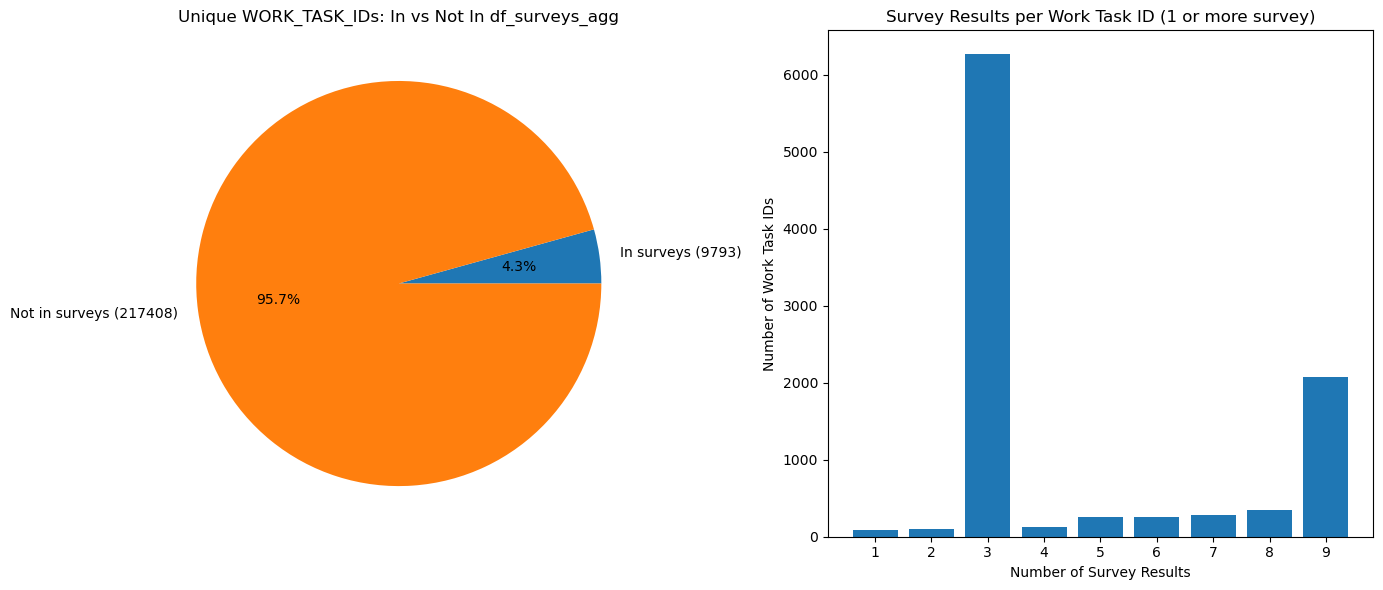

In [26]:
import pandas as pd

# Get unique WORK_TASK_IDs from df_tickets_assets
tickets_assets_ids = set(df_tickets_assets['WORK_TASK_ID'].unique())

# Get unique WORK_TASK_IDs from df_surveys_avg
surveys_agg_ids = set(df_surveys_agg['WORK_TASK_ID'].unique())

# Find WORK_TASK_IDs in df_tickets_assets that are not in df_surveys_avg
ids_only_in_tickets_assets = list(tickets_assets_ids - surveys_agg_ids)

# Filter df_tickets_assets to get rows with these IDs
df_tickets_assets_not_in_surveys = df_tickets_assets[df_tickets_assets['WORK_TASK_ID'].isin(ids_only_in_tickets_assets)]

print(f"Number of unique WORK_TASK_IDs in df_tickets_assets: {len(tickets_assets_ids)}")
print(f"Number of unique WORK_TASK_IDs in df_surveys_agg: {len(surveys_agg_ids)}")
print(f"Number of unique WORK_TASK_IDs in df_tickets_assets but not in df_surveys_agg: {len(ids_only_in_tickets_assets)}")


# Get the WORK_TASK_IDs from the most frequent entries in df_surveys
most_frequent_work_task_ids = df_surveys['WORK_TASK_ID'].value_counts().index.tolist()

# Filter df_tickets_assets_surveys for these WORK_TASK_IDs
matching_rows = df_tickets_assets_surveys[df_tickets_assets_surveys['WORK_TASK_ID'].isin(most_frequent_work_task_ids)]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# -===-
# Plots
# -===-
in_surveys = len(tickets_assets_ids & surveys_agg_ids)
not_in_surveys = len(ids_only_in_tickets_assets)

ax1.pie(
    [in_surveys, not_in_surveys],
    labels=[f'In surveys ({in_surveys})', f'Not in surveys ({not_in_surveys})'],
    autopct='%1.1f%%'
)
ax1.set_title('Unique WORK_TASK_IDs: In vs Not In df_surveys_agg')

# Bar chart
survey_counts = df_surveys['WORK_TASK_ID'].value_counts()
survey_counts_filtered = survey_counts[(survey_counts >= 1) & (survey_counts <= 9)]
binned = survey_counts_filtered.value_counts().sort_index()

ax2.bar(binned.index, binned.values)
ax2.set_xlabel('Number of Survey Results')
ax2.set_ylabel('Number of Work Task IDs')
ax2.set_title('Survey Results per Work Task ID (1 or more survey)')
ax2.set_xticks(range(1, 10))

plt.tight_layout()
plt.show()


### Important note about survey data

**The plots above show that:**
1. Most tickets **do not** have surveys attached
2. Tickets with surveys attached *typically* have 3 or 9 survey entries (describing unique user input to survey questions)

In [13]:
asset_recurrence_counts = df_tickets_filtered_by_asset['ASSET_NAME'].value_counts()

print("Recurrence counts of ASSET_NAME calculated:")
print(asset_recurrence_counts.head())

Recurrence counts of ASSET_NAME calculated:
ASSET_NAME
VAN-FEP-04    1
Name: count, dtype: int64


# Explore Assets with More than 1 Repetitive Task

Here, we will do some data exploration on the assets that are repeatedly being fixed.

In [15]:
import pandas as pd

# Get a list of ASSET_IDs that have more than one repetitive task
# This means they are actually contributing to the 'repetitive_tasks_by_asset_list'
repetitive_asset_ids = df_tickets_filtered_by_asset['ASSET_ID'].value_counts()
repetitive_asset_ids = repetitive_asset_ids[repetitive_asset_ids > 1].index.tolist()

print(f"Found {len(repetitive_asset_ids)} assets with more than one repetitive task.")

if not repetitive_asset_ids:
    print("No assets found with more than one repetitive task to analyze further.")
else:
    # Select a few assets for detailed inspection (e.g., the first 3)
    assets_to_inspect = repetitive_asset_ids[:3]

    for asset_id in assets_to_inspect:
        print(f"\n--- Analyzing ASSET_ID: {asset_id} ---")

        # Get all tasks for this specific asset from the originally filtered data (df_merged_assets)
        # not just the ones deemed 'repetitive' by the previous 90-day filter
        asset_tasks = df_merged_assets[df_merged_assets['ASSET_ID'] == asset_id].copy()

        # Sort these tasks by time
        asset_tasks_sorted = asset_tasks.sort_values(by='BASELINE_START_LTZ').reset_index(drop=True)

        if len(asset_tasks_sorted) < 2:
            print("  Not enough tasks for this asset to calculate time differences.")
            continue

        print(f"  Number of tasks for this asset: {len(asset_tasks_sorted)}")

        # Calculate time differences between consecutive tasks
        time_differences = asset_tasks_sorted['BASELINE_START_LTZ'].diff().dropna()

        if not time_differences.empty:
            print("  Consecutive task time differences:")
            for diff in time_differences:
                print(f"    - {diff}")
        else:
            print("  No consecutive time differences found.")

    print("\nThis analysis should help understand if the repetitions are indeed very close in time across the dataset.")

Found 0 assets with more than one repetitive task.
No assets found with more than one repetitive task to analyze further.


# ---------------------------------------
# EVERYTHING BELOW THIS POINT IS OUTDATED.
# ---------------------------------------

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of instances for each unique 'BUILDING'
building_counts = repeated_tasks_df['BUILDING'].value_counts().sort_values(ascending=False)


## [OLD] This bar chart is hard to read, so let's create an **interactive html page** with the data.


You can find this html file in `/content/sample_data/repeated_tasks_per_building_interactive.html`.